In [1]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

print("Stitching files together...")

files = ['BMW_bike.csv', 'ducatti_bike.csv', 'KTM_bike.csv', 'Royal_Enfield_Standard_bike.csv', 'Suzuki_bike.csv', 'Yamaha_bike.csv']
year_renamer = {'Types and Used Time': 'year_raw', 'Time of USed': 'year_raw', 'Types ': 'year_raw', 'Types and Used  Time': 'year_raw'}
model_renamer = {'Bike': 'model', 'Bike name ': 'model', 'bike': 'model', 'BIke name': 'model', 'Bike name': 'model'}

all_dfs = []
for file in files:
    temp_df = pd.read_csv(f'data/{file}', encoding='latin-1', on_bad_lines='skip')
    temp_df = temp_df.rename(columns=year_renamer)
    temp_df = temp_df.rename(columns=model_renamer)
    temp_df['brand'] = file.split('_')[0]
    all_dfs.append(temp_df)

df = pd.concat(all_dfs, ignore_index=True)

# Clean the core numbers
df['price'] = df['price'].str.replace('$', '', regex=False).str.replace(',', '', regex=False)
df['price'] = pd.to_numeric(df['price'], errors='coerce')

df['mileage'] = df['mileage'].str.replace(' miles', '', regex=False).str.replace(',', '', regex=False)
df['mileage'] = pd.to_numeric(df['mileage'], errors='coerce')

# Rescue New Bikes
is_new_bike = df['year_raw'].str.contains('New', na=False)
df.loc[is_new_bike & df['mileage'].isnull(), 'mileage'] = 0

# Extract Year and Engine Size
df['year'] = df['year_raw'].str.extract(r'(\d{4})', expand=False)
df['year'] = pd.to_numeric(df['year'], errors='coerce')

df['engine_size'] = df['model'].str.extract(r'(\d{2,4})')
df['engine_size'] = pd.to_numeric(df['engine_size'], errors='coerce')

# 1. Filter to ONLY the columns you requested (plus price)
df_clean = df[['brand', 'model', 'year', 'mileage', 'engine_size', 'price']]

# 2. Drop rows where we couldn't figure out the basic info
df_clean = df_clean.dropna(subset=['year', 'price'])

# 3. Sort alphabetically by Brand
df_clean = df_clean.sort_values(by='brand')

# 4. Save to a physical file!
df_clean.to_csv('combined_motorcycles.csv', index=False)

print(" Success! Check your folder for 'combined_motorcycles.csv'")
df_clean.head()

Stitching files together...
 Success! Check your folder for 'combined_motorcycles.csv'


,brand,model,year,mileage,engine_size,price
0,BMW,R 18 TRANSCONTINENTAL,2022,500.0,18.0,19994.0
853,BMW,K 1600 B,2023,0.0,1600.0,28820.0
852,BMW,K 1600 B,2023,0.0,1600.0,28820.0
851,BMW,K 1600 B,2023,0.0,1600.0,33200.0
850,BMW,K 1600 B,2023,0.0,1600.0,26655.0


In [2]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

print("Starting the stitching process...")

files = ['BMW_bike.csv', 'ducatti_bike.csv', 'KTM_bike.csv', 'Royal_Enfield_Standard_bike.csv', 'Suzuki_bike.csv', 'Yamaha_bike.csv']
year_renamer = {'Types and Used Time': 'year_raw', 'Time of USed': 'year_raw', 'Types ': 'year_raw', 'Types and Used  Time': 'year_raw'}
model_renamer = {'Bike': 'model', 'Bike name ': 'model', 'bike': 'model', 'BIke name': 'model', 'Bike name': 'model'}

all_dfs = []
for file in files:
    temp_df = pd.read_csv(f'data/{file}', encoding='latin-1', on_bad_lines='skip')
    temp_df = temp_df.rename(columns=year_renamer)
    temp_df = temp_df.rename(columns=model_renamer)
    temp_df['brand'] = file.split('_')[0]
    all_dfs.append(temp_df)

df = pd.concat(all_dfs, ignore_index=True)

# 1. Clean Numbers
df['price'] = df['price'].str.replace('$', '', regex=False).str.replace(',', '', regex=False)
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df['mileage'] = df['mileage'].str.replace(' miles', '', regex=False).str.replace(',', '', regex=False)
df['mileage'] = pd.to_numeric(df['mileage'], errors='coerce')

# 2. Rescue New Bikes
is_new_bike = df['year_raw'].str.contains('New', na=False)
df.loc[is_new_bike & df['mileage'].isnull(), 'mileage'] = 0

# 3. Extract Year & Engine Size
df['year'] = df['year_raw'].str.extract(r'(\d{4})', expand=False)
df['year'] = pd.to_numeric(df['year'], errors='coerce')
df['engine_size'] = df['model'].str.extract(r'(\d{2,4})')
df['engine_size'] = pd.to_numeric(df['engine_size'], errors='coerce')

# 4. DEALING WITH MISSING ENGINE SIZES (The Grouped Average Imputation!)
# If a bike has no engine size, we fill it with the average engine size of its specific Brand.
df['engine_size'] = df.groupby('brand')['engine_size'].transform(lambda x: x.fillna(x.mean()))

# 5. Final Cleanup & Export
df_clean = df[['brand', 'model', 'year', 'mileage', 'engine_size', 'price']]
df_clean = df_clean.dropna(subset=['year', 'price', 'mileage', 'engine_size'])
df_clean = df_clean.sort_values(by='brand')

df_clean.to_csv('combined_motorcycles.csv', index=False)
print(f"✅ Success! Saved {len(df_clean)} bikes to 'combined_motorcycles.csv'")

Starting the stitching process...
✅ Success! Saved 7278 bikes to 'combined_motorcycles.csv'


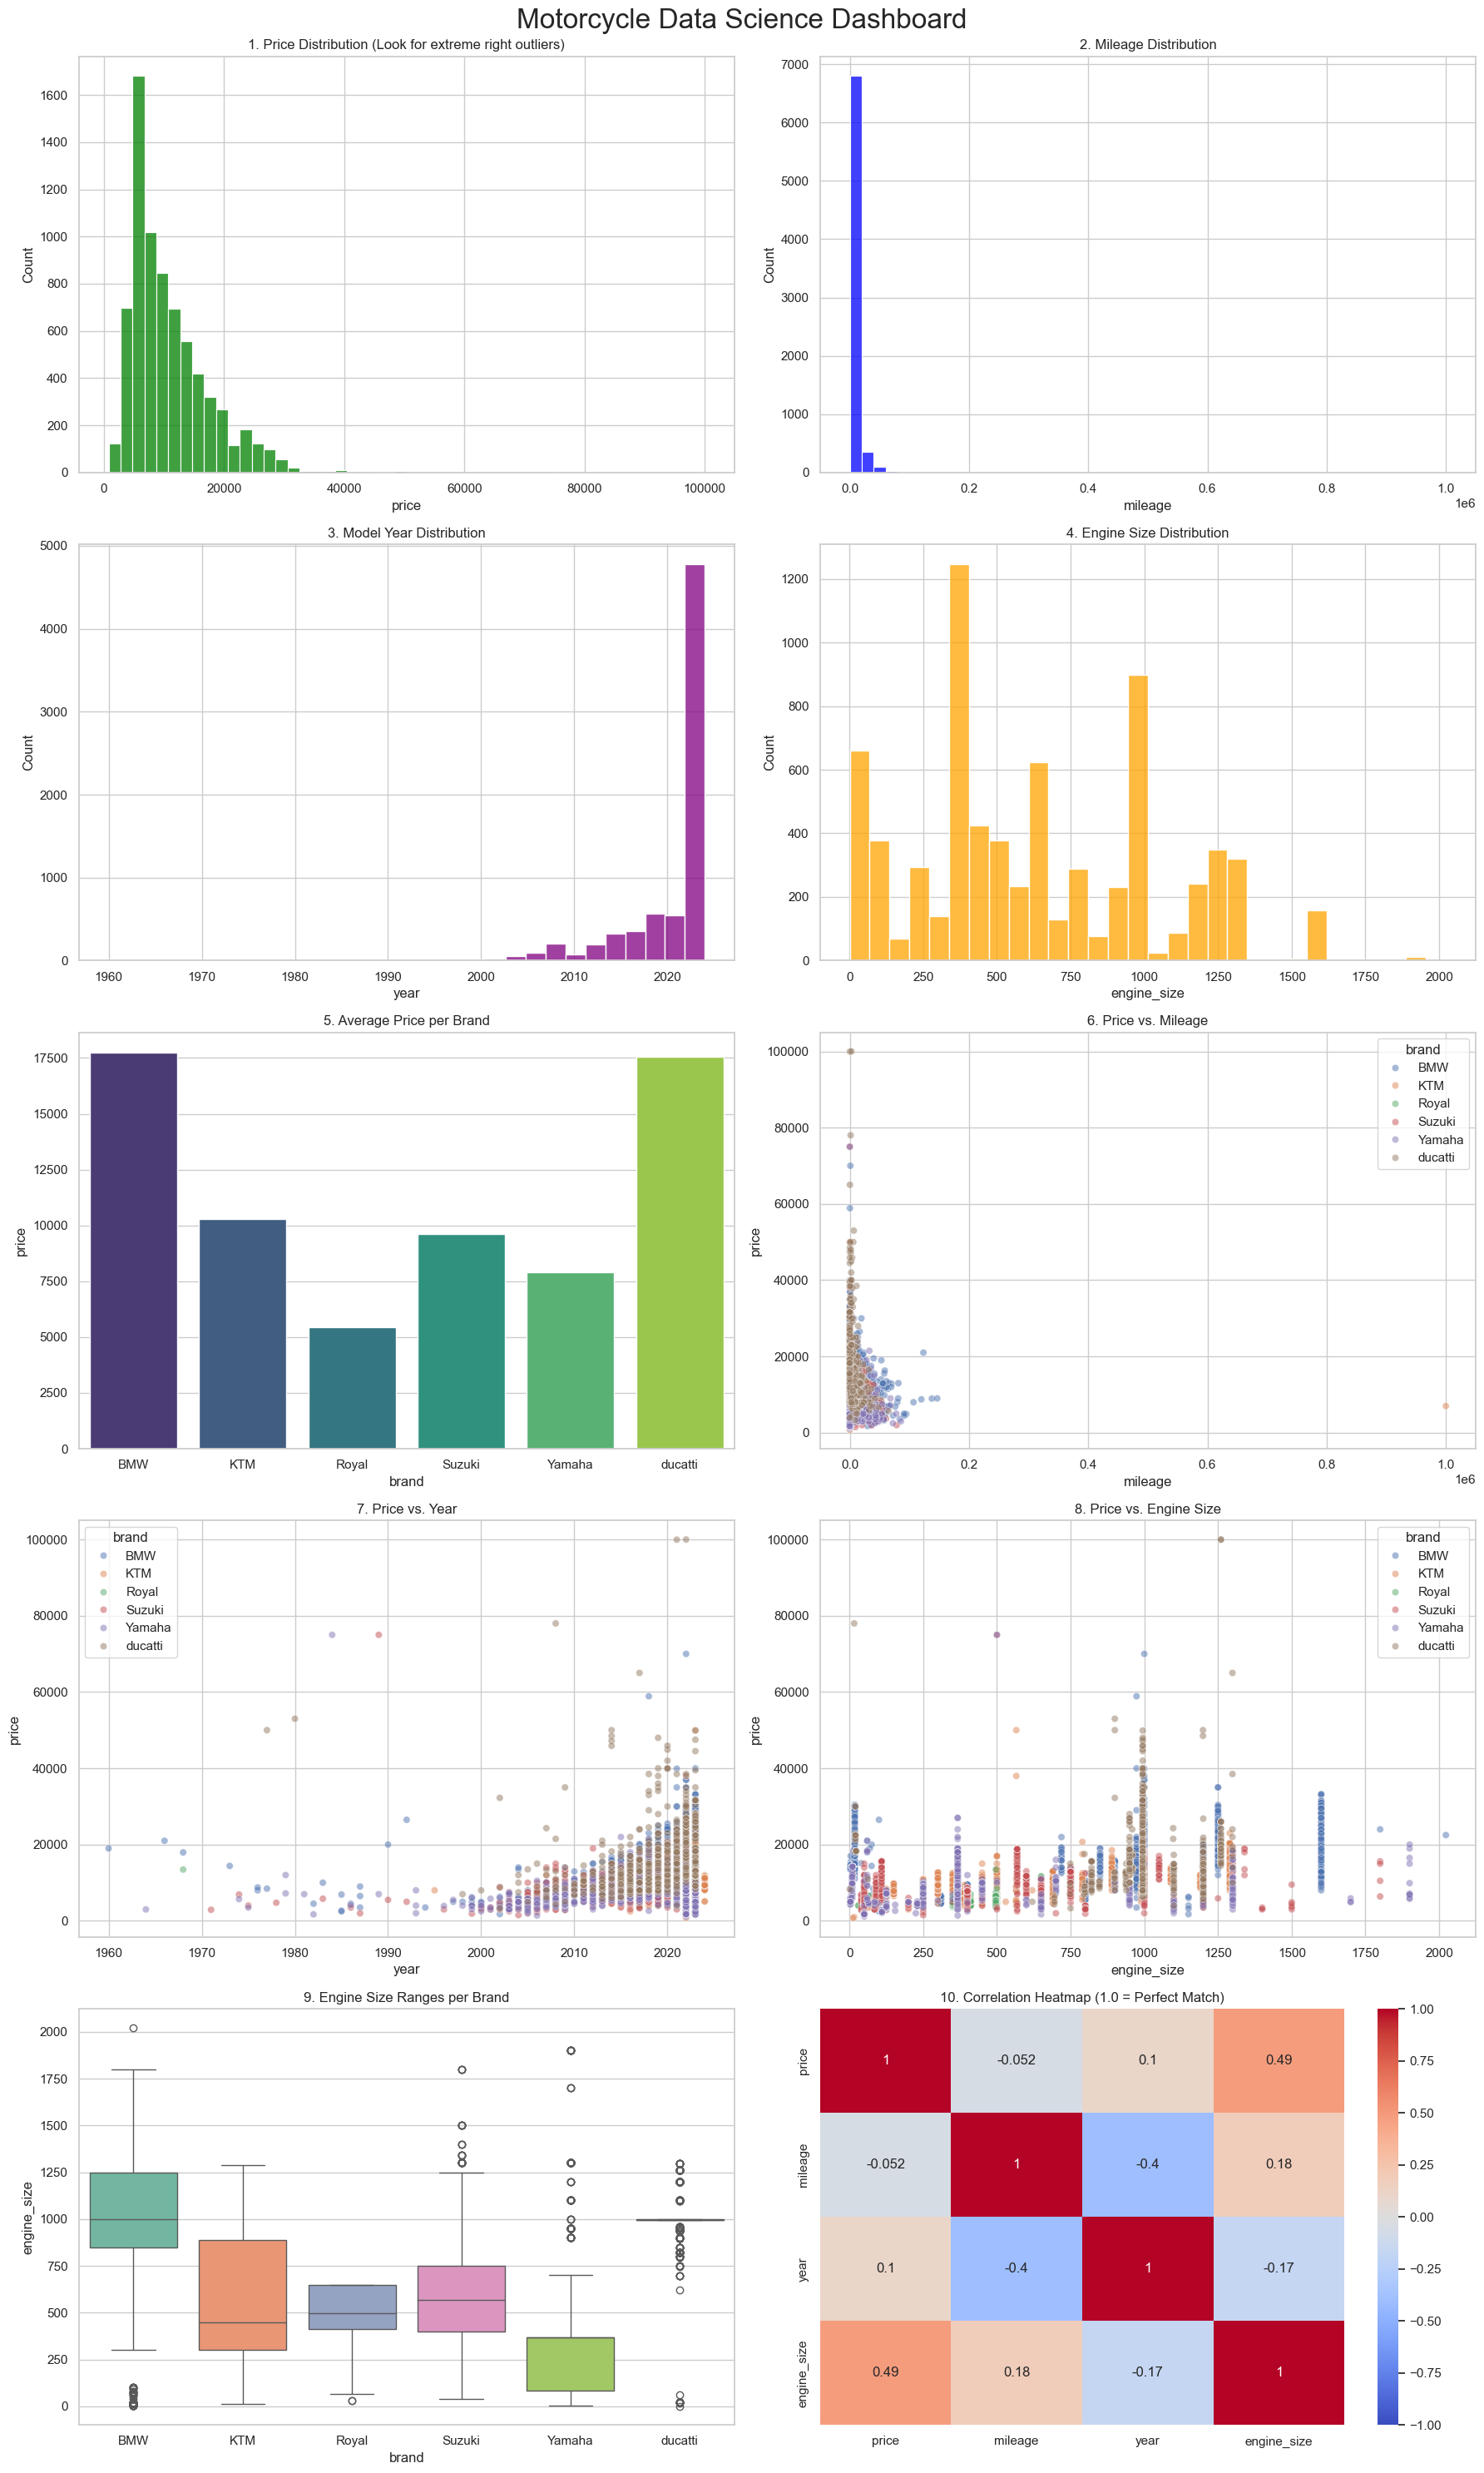

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the clean data
df_viz = pd.read_csv('combined_motorcycles.csv')

# Setup a massive 5x2 grid for 10 charts
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(5, 2, figsize=(18, 30))
fig.suptitle('Motorcycle Data Science Dashboard', fontsize=24, y=0.99)

# 1. Price Distribution
sns.histplot(df_viz['price'], bins=50, ax=axes[0,0], color='green')
axes[0,0].set_title('1. Price Distribution (Look for extreme right outliers)')

# 2. Mileage Distribution
sns.histplot(df_viz['mileage'], bins=50, ax=axes[0,1], color='blue')
axes[0,1].set_title('2. Mileage Distribution')

# 3. Year Distribution
sns.histplot(df_viz['year'], bins=30, ax=axes[1,0], color='purple')
axes[1,0].set_title('3. Model Year Distribution')

# 4. Engine Size Distribution
sns.histplot(df_viz['engine_size'], bins=30, ax=axes[1,1], color='orange')
axes[1,1].set_title('4. Engine Size Distribution')

# 5. Average Price by Brand
sns.barplot(x='brand', y='price', data=df_viz, ax=axes[2,0], errorbar=None, palette='viridis')
axes[2,0].set_title('5. Average Price per Brand')

# 6. Price vs. Mileage (Scatter)
sns.scatterplot(x='mileage', y='price', hue='brand', alpha=0.5, data=df_viz, ax=axes[2,1])
axes[2,1].set_title('6. Price vs. Mileage')

# 7. Price vs. Year (Scatter)
sns.scatterplot(x='year', y='price', hue='brand', alpha=0.5, data=df_viz, ax=axes[3,0])
axes[3,0].set_title('7. Price vs. Year')

# 8. Price vs. Engine Size (Scatter)
sns.scatterplot(x='engine_size', y='price', hue='brand', alpha=0.5, data=df_viz, ax=axes[3,1])
axes[3,1].set_title('8. Price vs. Engine Size')

# 9. Engine Size by Brand (Boxplot)
sns.boxplot(x='brand', y='engine_size', data=df_viz, ax=axes[4,0], palette='Set2')
axes[4,0].set_title('9. Engine Size Ranges per Brand')

# 10. The Correlation Matrix (What drives price?)
num_cols = df_viz[['price', 'mileage', 'year', 'engine_size']]
sns.heatmap(num_cols.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1, ax=axes[4,1])
axes[4,1].set_title('10. Correlation Heatmap (1.0 = Perfect Match)')

plt.tight_layout()
plt.show()

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Load Data and Filter Outliers (Bikes over $40k ruin the math)
df_ml = pd.read_csv('combined_motorcycles.csv')
df_ml = df_ml[df_ml['price'] < 40000]

# 2. Encode Brands to Math
df_encoded = pd.get_dummies(df_ml, columns=['brand'], dtype=int)

# 3. Define Features and Split Data
feature_cols = ['year', 'mileage', 'engine_size'] + [col for col in df_encoded.columns if 'brand_' in col]
X = df_encoded[feature_cols]
y = df_encoded['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Scale Data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Train Neural Network
print("Training Neural Network...")
nn_model = MLPRegressor(hidden_layer_sizes=(128, 64, 32), activation='relu', max_iter=500, random_state=42)
nn_model.fit(X_train_scaled, y_train)

# 6. Evaluate
nn_predictions = nn_model.predict(X_test_scaled)
nn_mae = mean_absolute_error(y_test, nn_predictions)
nn_r2 = r2_score(y_test, nn_predictions)

print("\n---  NEURAL NETWORK REPORT CARD 1.0 ---")
print(f"Average Price Error: Off by ${nn_mae:,.2f}")
print(f"Accuracy Score (R-squared): {nn_r2:.2f}")

Training Neural Network...

---  NEURAL NETWORK REPORT CARD 1.0 ---
Average Price Error: Off by $2,078.89
Accuracy Score (R-squared): 0.75


In [5]:
from sklearn.ensemble import RandomForestRegressor

print("Training Random Forest...")
# Random Forests use hundreds of "Decision Trees" to vote on the final price
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# We use the exact same scaled training data from Cell 3!
rf_model.fit(X_train_scaled, y_train)

# Take the final exam
rf_predictions = rf_model.predict(X_test_scaled)
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_r2 = r2_score(y_test, rf_predictions)

print("\n---  RANDOM FOREST REPORT CARD 1.0 ---")
print(f"Average Price Error: Off by ${rf_mae:,.2f}")
print(f"Accuracy Score (R-squared): {rf_r2:.2f}")

# The Head-to-Head Winner:
print("\n---  THE SHOWDOWN ---")
diff = nn_mae - rf_mae
if diff > 0:
    print(f"Random Forest won by ${diff:,.2f} per prediction!")
else:
    print(f"Neural Network won by ${abs(diff):,.2f} per prediction!")

Training Random Forest...

---  RANDOM FOREST REPORT CARD 1.0 ---
Average Price Error: Off by $1,563.25
Accuracy Score (R-squared): 0.80

---  THE SHOWDOWN ---
Random Forest won by $515.64 per prediction!


In [6]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

print("Stitching files and DROPPING missing engine sizes...")

files = ['BMW_bike.csv', 'ducatti_bike.csv', 'KTM_bike.csv', 'Royal_Enfield_Standard_bike.csv', 'Suzuki_bike.csv', 'Yamaha_bike.csv']
year_renamer = {'Types and Used Time': 'year_raw', 'Time of USed': 'year_raw', 'Types ': 'year_raw', 'Types and Used  Time': 'year_raw'}
model_renamer = {'Bike': 'model', 'Bike name ': 'model', 'bike': 'model', 'BIke name': 'model', 'Bike name': 'model'}

all_dfs = []
for file in files:
    temp_df = pd.read_csv(f'data/{file}', encoding='latin-1', on_bad_lines='skip')
    temp_df = temp_df.rename(columns=year_renamer)
    temp_df = temp_df.rename(columns=model_renamer)
    temp_df['brand'] = file.split('_')[0]
    all_dfs.append(temp_df)

df = pd.concat(all_dfs, ignore_index=True)

# 1. Clean Numbers
df['price'] = df['price'].str.replace('$', '', regex=False).str.replace(',', '', regex=False)
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df['mileage'] = df['mileage'].str.replace(' miles', '', regex=False).str.replace(',', '', regex=False)
df['mileage'] = pd.to_numeric(df['mileage'], errors='coerce')

# 2. Rescue New Bikes
is_new_bike = df['year_raw'].str.contains('New', na=False)
df.loc[is_new_bike & df['mileage'].isnull(), 'mileage'] = 0

# 3. Extract Year & Engine Size
df['year'] = df['year_raw'].str.extract(r'(\d{4})', expand=False)
df['year'] = pd.to_numeric(df['year'], errors='coerce')
df['engine_size'] = df['model'].str.extract(r'(\d{2,4})')
df['engine_size'] = pd.to_numeric(df['engine_size'], errors='coerce')

# 4. THE BIG CHANGE: Do NOT impute. Just drop anything missing an engine size!
df_clean = df[['brand', 'model', 'year', 'mileage', 'engine_size', 'price']]
df_clean = df_clean.dropna(subset=['year', 'price', 'mileage', 'engine_size'])

# Filter out extreme outliers so our models and graphs work perfectly
df_clean = df_clean[df_clean['price'] < 40000]
df_clean = df_clean.sort_values(by='brand')

# Save to a NEW file so we don't overwrite the old one
df_clean.to_csv('combined_strict_motorcycles.csv', index=False)
print(f" Success! Saved {len(df_clean)} strict bikes to 'combined_strict_motorcycles.csv'")

Stitching files and DROPPING missing engine sizes...
 Success! Saved 5905 strict bikes to 'combined_strict_motorcycles.csv'


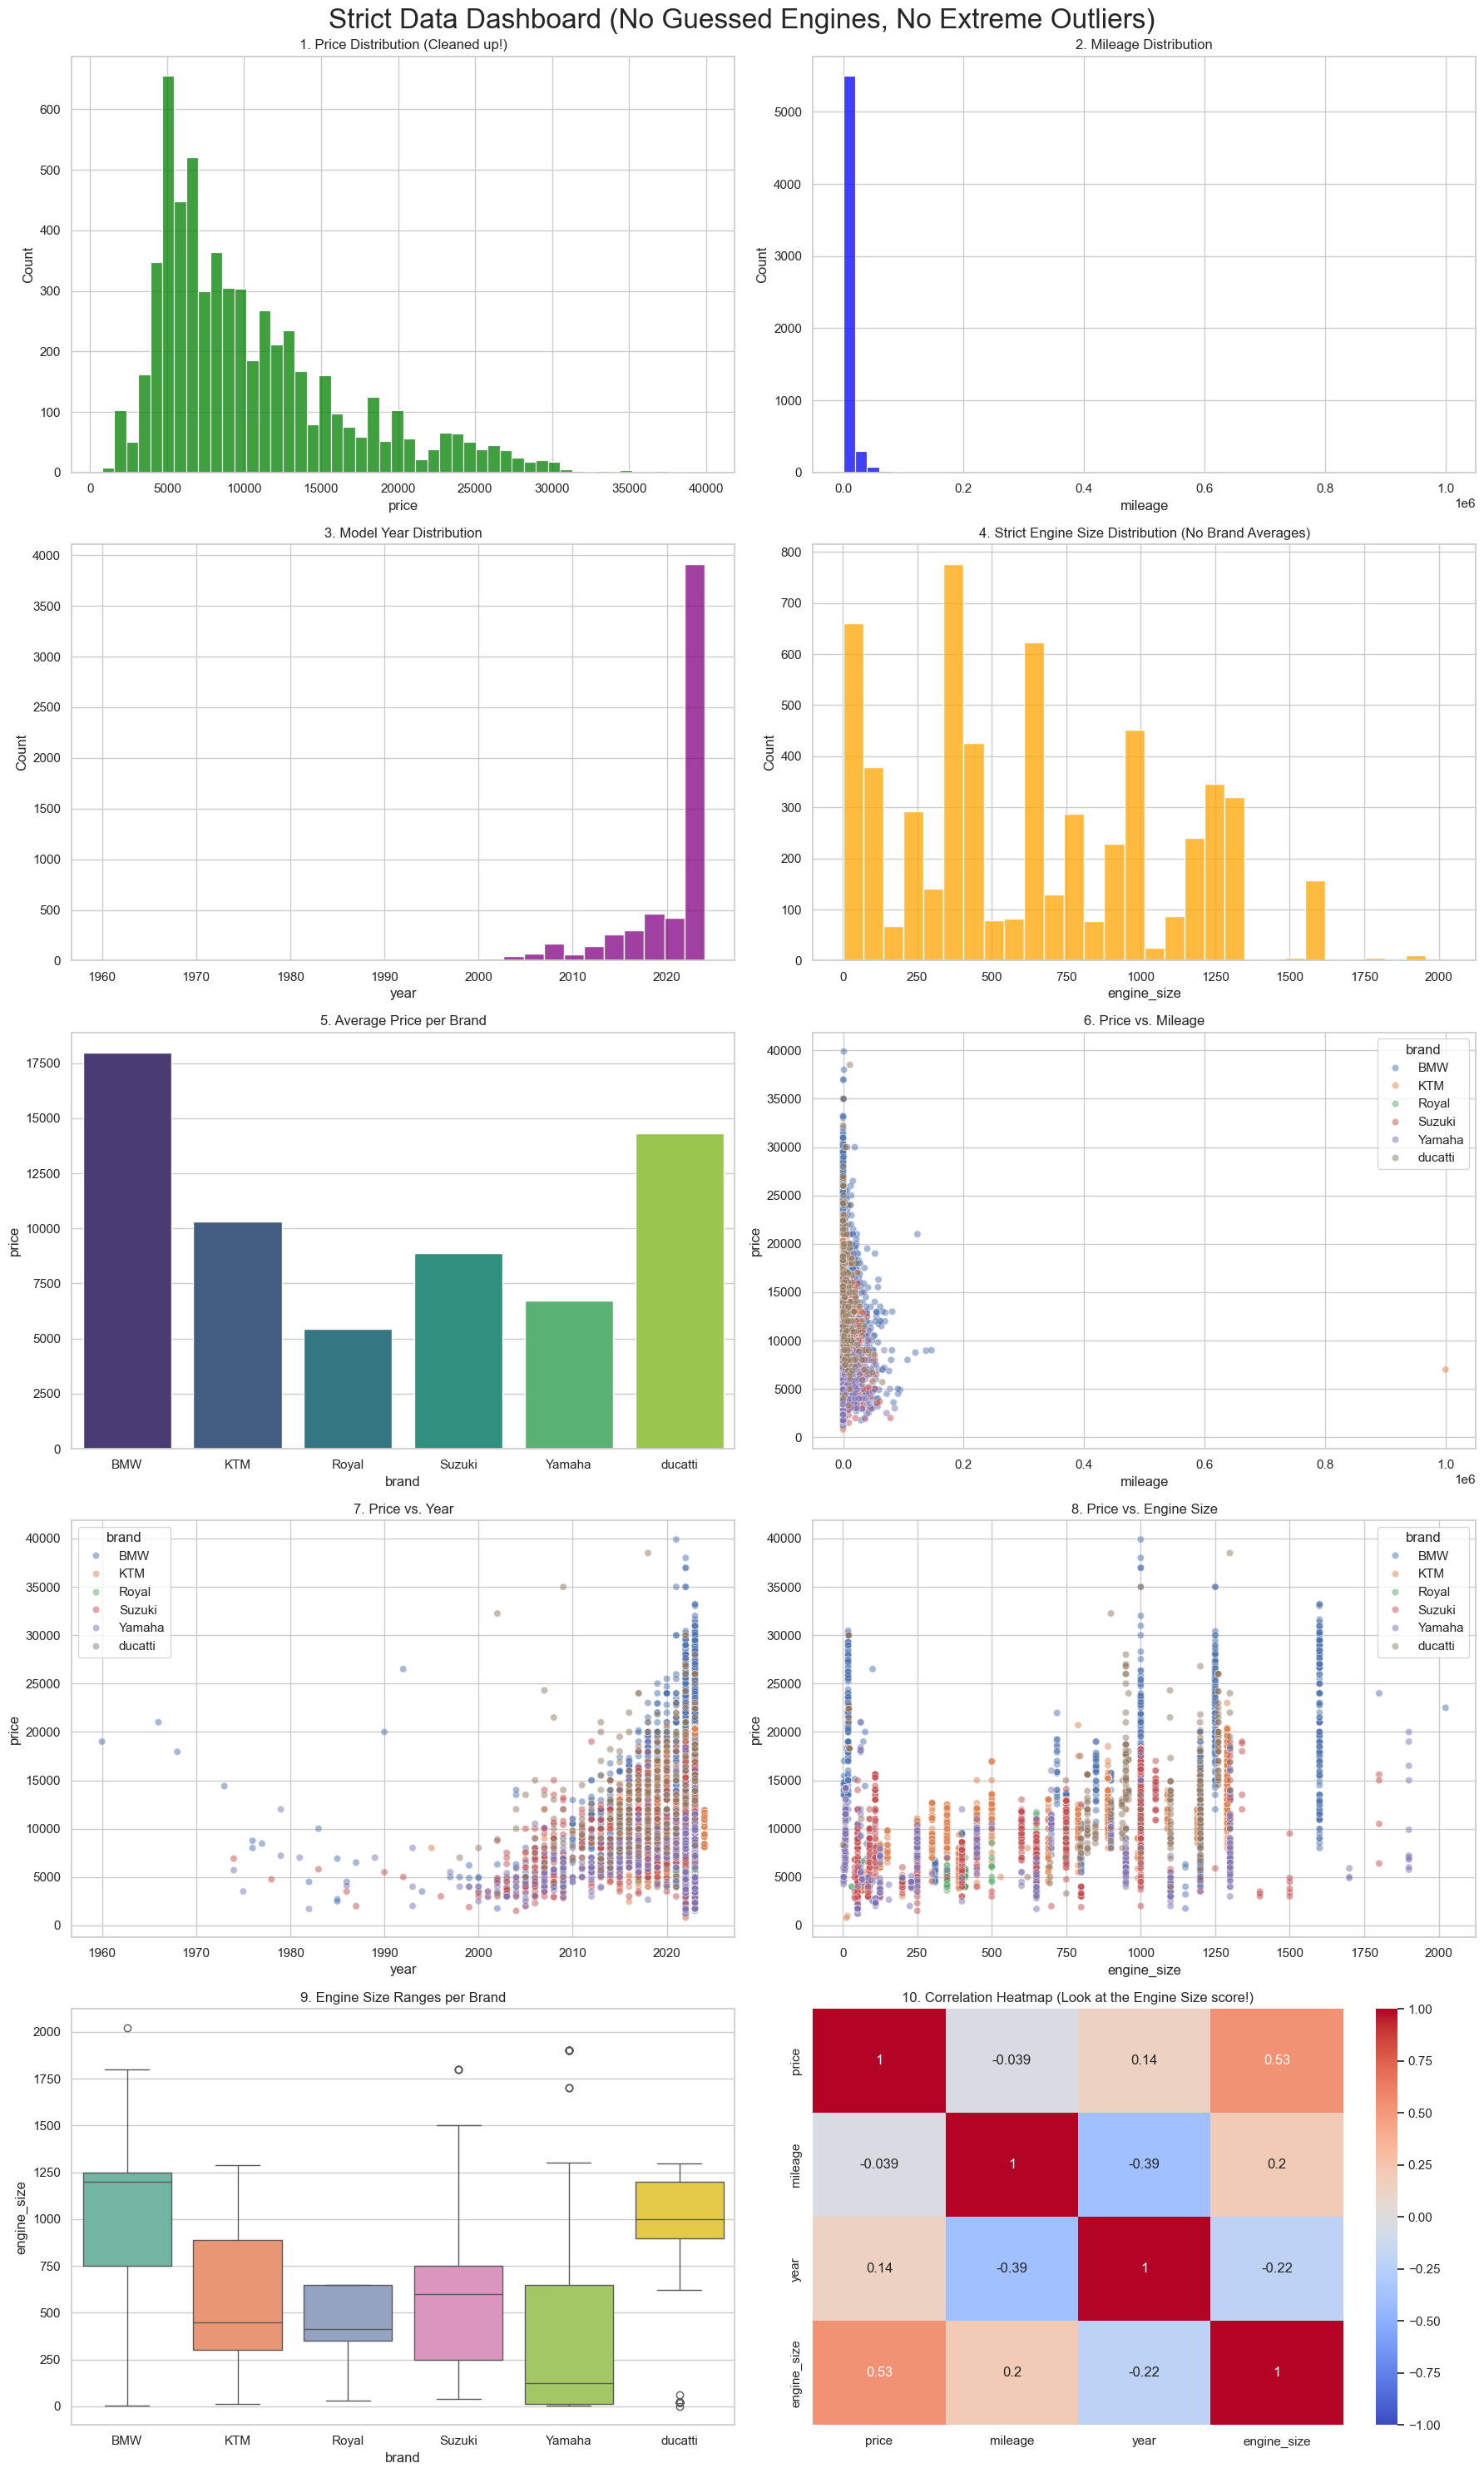

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_viz = pd.read_csv('combined_strict_motorcycles.csv')

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(5, 2, figsize=(18, 30))
fig.suptitle('Strict Data Dashboard (No Guessed Engines, No Extreme Outliers)', fontsize=24, y=0.99)

# 1. Price Distribution
sns.histplot(df_viz['price'], bins=50, ax=axes[0,0], color='green')
axes[0,0].set_title('1. Price Distribution (Cleaned up!)')

# 2. Mileage Distribution
sns.histplot(df_viz['mileage'], bins=50, ax=axes[0,1], color='blue')
axes[0,1].set_title('2. Mileage Distribution')

# 3. Year Distribution
sns.histplot(df_viz['year'], bins=30, ax=axes[1,0], color='purple')
axes[1,0].set_title('3. Model Year Distribution')

# 4. Engine Size Distribution
sns.histplot(df_viz['engine_size'], bins=30, ax=axes[1,1], color='orange')
axes[1,1].set_title('4. Strict Engine Size Distribution (No Brand Averages)')

# 5. Average Price by Brand
sns.barplot(x='brand', y='price', data=df_viz, ax=axes[2,0], errorbar=None, palette='viridis')
axes[2,0].set_title('5. Average Price per Brand')

# 6. Price vs. Mileage
sns.scatterplot(x='mileage', y='price', hue='brand', alpha=0.5, data=df_viz, ax=axes[2,1])
axes[2,1].set_title('6. Price vs. Mileage')

# 7. Price vs. Year
sns.scatterplot(x='year', y='price', hue='brand', alpha=0.5, data=df_viz, ax=axes[3,0])
axes[3,0].set_title('7. Price vs. Year')

# 8. Price vs. Engine Size
sns.scatterplot(x='engine_size', y='price', hue='brand', alpha=0.5, data=df_viz, ax=axes[3,1])
axes[3,1].set_title('8. Price vs. Engine Size')

# 9. Engine Size by Brand
sns.boxplot(x='brand', y='engine_size', data=df_viz, ax=axes[4,0], palette='Set2')
axes[4,0].set_title('9. Engine Size Ranges per Brand')

# 10. The Correlation Matrix
num_cols = df_viz[['price', 'mileage', 'year', 'engine_size']]
sns.heatmap(num_cols.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1, ax=axes[4,1])
axes[4,1].set_title('10. Correlation Heatmap (Look at the Engine Size score!)')

plt.tight_layout()
plt.show()

In [8]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Load the NEW strict dataset
df_rf = pd.read_csv('combined_strict_motorcycles.csv')
df_encoded = pd.get_dummies(df_rf, columns=['brand'], dtype=int)

feature_cols = ['year', 'mileage', 'engine_size'] + [col for col in df_encoded.columns if 'brand_' in col]
X = df_encoded[feature_cols]
y = df_encoded['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training Random Forest on Strict Data...")
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

rf_predictions = rf_model.predict(X_test_scaled)
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_r2 = r2_score(y_test, rf_predictions)

print("\n---  STRICT RANDOM FOREST REPORT CARD ---")
print(f"Average Price Error: Off by ${rf_mae:,.2f}")
print(f"Accuracy Score (R-squared): {rf_r2:.2f}")

Training Random Forest on Strict Data...

---  STRICT RANDOM FOREST REPORT CARD ---
Average Price Error: Off by $1,213.74
Accuracy Score (R-squared): 0.89


In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Load the NEW strict dataset
df_nn = pd.read_csv('combined_strict_motorcycles.csv')
df_encoded = pd.get_dummies(df_nn, columns=['brand'], dtype=int)

feature_cols = ['year', 'mileage', 'engine_size'] + [col for col in df_encoded.columns if 'brand_' in col]
X = df_encoded[feature_cols]
y = df_encoded['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training Neural Network on Strict Data...")
nn_model = MLPRegressor(hidden_layer_sizes=(128, 64, 32), activation='relu', max_iter=500, random_state=42)
nn_model.fit(X_train_scaled, y_train)

nn_predictions = nn_model.predict(X_test_scaled)
nn_mae = mean_absolute_error(y_test, nn_predictions)
nn_r2 = r2_score(y_test, nn_predictions)

print("\n---  STRICT NEURAL NETWORK REPORT CARD ---")
print(f"Average Price Error: Off by ${nn_mae:,.2f}")
print(f"Accuracy Score (R-squared): {nn_r2:.2f}")

Training Neural Network on Strict Data...

---  STRICT NEURAL NETWORK REPORT CARD ---
Average Price Error: Off by $1,727.07
Accuracy Score (R-squared): 0.81


In [10]:
#!pip install xgboost -q
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# 1. Load the Imputed Data (Where we guessed missing engine sizes)
df_imputed = pd.read_csv('combined_motorcycles.csv')
df_imputed = df_imputed[df_imputed['price'] < 40000] # Outlier filter

df_encoded = pd.get_dummies(df_imputed, columns=['brand'], dtype=int)
feature_cols = ['year', 'mileage', 'engine_size'] + [col for col in df_encoded.columns if 'brand_' in col]

X = df_encoded[feature_cols]
y = df_encoded['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training Standard XGBoost on Imputed Data...")
# XGBoost defaults: 100 trees, standard learning rate
xgb_model = XGBRegressor(random_state=42)
xgb_model.fit(X_train_scaled, y_train)

preds = xgb_model.predict(X_test_scaled)
mae = mean_absolute_error(y_test, preds)

print("\n---  XGBOOST (IMPUTED DATA) ---")
print(f"Average Price Error: Off by ${mae:,.2f}")

Training Standard XGBoost on Imputed Data...

---  XGBOOST (IMPUTED DATA) ---
Average Price Error: Off by $1,557.50


In [11]:
# 1. Load the Strict Data (Dropped missing engines)
df_strict = pd.read_csv('combined_strict_motorcycles.csv')
df_strict = df_strict[df_strict['price'] < 40000]

df_encoded_strict = pd.get_dummies(df_strict, columns=['brand'], dtype=int)
feature_cols_strict = ['year', 'mileage', 'engine_size'] + [col for col in df_encoded_strict.columns if 'brand_' in col]

X_strict = df_encoded_strict[feature_cols_strict]
y_strict = df_encoded_strict['price']
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_strict, y_strict, test_size=0.2, random_state=42)

scaler_strict = StandardScaler()
X_train_s_scaled = scaler_strict.fit_transform(X_train_s)
X_test_s_scaled = scaler_strict.transform(X_test_s)

print("Training Standard XGBoost on Strict Data...")
xgb_model_strict = XGBRegressor(random_state=42)
xgb_model_strict.fit(X_train_s_scaled, y_train_s)

preds_strict = xgb_model_strict.predict(X_test_s_scaled)
mae_strict = mean_absolute_error(y_test_s, preds_strict)

print("\n---  XGBOOST (STRICT DATA) ---")
print(f"Average Price Error: Off by ${mae_strict:,.2f}")

Training Standard XGBoost on Strict Data...

---  XGBOOST (STRICT DATA) ---
Average Price Error: Off by $1,228.03


In [12]:
from sklearn.model_selection import GridSearchCV

print("Running Grid Search on Imputed Data... (This will take a minute!)")

# The exact settings we want the computer to test
param_grid = {
    'n_estimators': [100, 200, 300],       # Number of trees
    'max_depth': [3, 5, 7],                # How deep the trees can go
    'learning_rate': [0.05, 0.1]           # How aggressively it corrects errors
}

# Setup the Grid Search
grid_imputed = GridSearchCV(
    XGBRegressor(random_state=42), 
    param_grid, 
    cv=3, # Tests each combo 3 times to be sure
    scoring='neg_mean_absolute_error',
    verbose=1
)

# Run the massive test!
grid_imputed.fit(X_train_scaled, y_train)

# Grab the absolute best model from the test
best_xgb_imputed = grid_imputed.best_estimator_
tuned_preds = best_xgb_imputed.predict(X_test_scaled)
tuned_mae = mean_absolute_error(y_test, tuned_preds)

print("\n---  TUNED XGBOOST (IMPUTED DATA) ---")
print(f"Best Settings Found: {grid_imputed.best_params_}")
print(f"Average Price Error: Off by ${tuned_mae:,.2f}")

Running Grid Search on Imputed Data... (This will take a minute!)
Fitting 3 folds for each of 18 candidates, totalling 54 fits

---  TUNED XGBOOST (IMPUTED DATA) ---
Best Settings Found: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 100}
Average Price Error: Off by $1,553.99


In [13]:
print("Running Grid Search on Strict Data... (This will take a minute!)")

# Setup the Grid Search for the strict dataset
grid_strict = GridSearchCV(
    XGBRegressor(random_state=42), 
    param_grid, # Using the same 18 combinations
    cv=3, 
    scoring='neg_mean_absolute_error',
    verbose=1
)

# Run the massive test!
grid_strict.fit(X_train_s_scaled, y_train_s)

# Grab the best model
best_xgb_strict = grid_strict.best_estimator_
tuned_preds_strict = best_xgb_strict.predict(X_test_s_scaled)
tuned_mae_strict = mean_absolute_error(y_test_s, tuned_preds_strict)

print("\n---  TUNED XGBOOST (STRICT DATA) ---")
print(f"Best Settings Found: {grid_strict.best_params_}")
print(f"Average Price Error: Off by ${tuned_mae_strict:,.2f}")

# THE GRAND CHAMPION REVEAL
print("\n=============================================")
print(" TOURNAMENT RESULTS ")
print(f"1. Standard XGBoost (Imputed Data): ${mae:,.2f}")
print(f"2. Standard XGBoost (Strict Data):  ${mae_strict:,.2f}")
print(f"3. Tuned XGBoost (Imputed Data):    ${tuned_mae:,.2f}")
print(f"4. Tuned XGBoost (Strict Data):     ${tuned_mae_strict:,.2f}")
print("=============================================")

Running Grid Search on Strict Data... (This will take a minute!)
Fitting 3 folds for each of 18 candidates, totalling 54 fits

---  TUNED XGBOOST (STRICT DATA) ---
Best Settings Found: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200}
Average Price Error: Off by $1,210.46

 TOURNAMENT RESULTS 
1. Standard XGBoost (Imputed Data): $1,557.50
2. Standard XGBoost (Strict Data):  $1,228.03
3. Tuned XGBoost (Imputed Data):    $1,553.99
4. Tuned XGBoost (Strict Data):     $1,210.46


In [14]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

print("1. Re-stitching Raw Files...")
files = ['BMW_bike.csv', 'ducatti_bike.csv', 'KTM_bike.csv', 'Royal_Enfield_Standard_bike.csv', 'Suzuki_bike.csv', 'Yamaha_bike.csv']
year_renamer = {'Types and Used Time': 'year_raw', 'Time of USed': 'year_raw', 'Types ': 'year_raw', 'Types and Used  Time': 'year_raw'}
model_renamer = {'Bike': 'model', 'Bike name ': 'model', 'bike': 'model', 'BIke name': 'model', 'Bike name': 'model'}

all_dfs = []
for file in files:
    temp_df = pd.read_csv(f'data/{file}', encoding='latin-1', on_bad_lines='skip')
    temp_df = temp_df.rename(columns=year_renamer)
    temp_df = temp_df.rename(columns=model_renamer)
    temp_df['brand'] = file.split('_')[0]
    all_dfs.append(temp_df)

df = pd.concat(all_dfs, ignore_index=True)

print("2. Cleaning and Rescuing Data...")
df['price'] = df['price'].str.replace('$', '', regex=False).str.replace(',', '', regex=False)
df['price'] = pd.to_numeric(df['price'], errors='coerce')

df['mileage'] = df['mileage'].str.replace(' miles', '', regex=False).str.replace(',', '', regex=False)
df['mileage'] = pd.to_numeric(df['mileage'], errors='coerce')

is_new_bike = df['year_raw'].str.contains('New', na=False)
df.loc[is_new_bike & df['mileage'].isnull(), 'mileage'] = 0

df['year'] = df['year_raw'].str.extract(r'(\d{4})', expand=False)
df['year'] = pd.to_numeric(df['year'], errors='coerce')

df['engine_size'] = df['model'].str.extract(r'(\d{2,4})')
df['engine_size'] = pd.to_numeric(df['engine_size'], errors='coerce')

# --- THE NEW MAGIC: EXTRACTING THE CATEGORY ---
print("3. Extracting Motorcycle Categories...")
# We scan the raw text for these specific keywords
categories = r'(Sportbike|Sport Touring|Touring|Cruiser|Standard|Dual Sport|Dirt Bike|Scooter|Super Moto|Custom|Adventure)'
df['category'] = df['year_raw'].str.extract(categories, expand=False)
# If the regex doesn't find anything, we label it 'Unknown' so we don't have to delete the bike
df['category'] = df['category'].fillna('Unknown')

# Strict dropping (No missing engine sizes allowed!)
df_clean = df.dropna(subset=['year', 'price', 'mileage', 'engine_size'])
df_clean = df_clean[df_clean['price'] < 40000] # Drop extreme outliers

df_clean.to_csv('combined_categorized_motorcycles.csv', index=False)

print("4. Encoding Brands AND Categories...")
# Notice we are now encoding BOTH brand and category into math!
df_encoded = pd.get_dummies(df_clean, columns=['brand', 'category'], dtype=int)

feature_cols = ['year', 'mileage', 'engine_size'] + [col for col in df_encoded.columns if 'brand_' in col or 'category_' in col]
X = df_encoded[feature_cols]
y = df_encoded['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("5. Training the Category-Aware Random Forest...")
rf_model = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42)
rf_model.fit(X_train_scaled, y_train)

rf_predictions = rf_model.predict(X_test_scaled)
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_r2 = r2_score(y_test, rf_predictions)

print("\n---  CATEGORY-AWARE REPORT CARD ---")
print(f"Total Bikes Analyzed: {len(df_clean)}")
print(f"Total Predictive Features (Including Yes/No columns): {len(feature_cols)}")
print(f"Average Price Error: Off by ${rf_mae:,.2f}")
print(f"Accuracy Score (R-squared): {rf_r2:.2f}")

1. Re-stitching Raw Files...
2. Cleaning and Rescuing Data...
3. Extracting Motorcycle Categories...
4. Encoding Brands AND Categories...
5. Training the Category-Aware Random Forest...

---  CATEGORY-AWARE REPORT CARD ---
Total Bikes Analyzed: 5905
Total Predictive Features (Including Yes/No columns): 20
Average Price Error: Off by $1,116.79
Accuracy Score (R-squared): 0.91


In [15]:
import pandas as pd

def appraise_motorcycle(brand, category, year, mileage, engine_size):
    # 1. Create a blank template with all our features set to 0
    input_data = {col: 0 for col in feature_cols}
    
    # 2. Fill in the numbers
    input_data['year'] = year
    input_data['mileage'] = mileage
    input_data['engine_size'] = engine_size
    
    # 3. Flip the correct "Yes/No" brand and category switches to 1
    brand_col = f'brand_{brand}'
    category_col = f'category_{category}'
    
    if brand_col in input_data:
        input_data[brand_col] = 1
    else:
        print(f"Warning: AI has never seen the brand '{brand}'")
        
    if category_col in input_data:
        input_data[category_col] = 1
    else:
        print(f"Warning: AI has never seen the category '{category}'")
        
    # 4. Package it up, scale it, and ask the AI!
    input_df = pd.DataFrame([input_data])
    input_scaled = scaler.transform(input_df)
    
    estimated_price = rf_model.predict(input_scaled)[0]
    
    print("\n=======================================")
    print(f" APPRAISAL: {year} {brand} ({category}, {engine_size}cc)")
    print(f" Mileage: {mileage:,} miles")
    print(f" ESTIMATED VALUE: ${estimated_price:,.2f}")
    print("=======================================\n")
    
    return estimated_price

# --- TEST IT OUT! ---
my_price = appraise_motorcycle(
    brand='Suzuki', 
    category='Dual Sport', 
    year=2022, 
    mileage=23600, 
    engine_size=400
)


 APPRAISAL: 2022 Suzuki (Dual Sport, 400cc)
 Mileage: 23,600 miles
 ESTIMATED VALUE: $7,093.44



In [16]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

print("1. Loading the Categorized Dataset...")
df = pd.read_csv('combined_categorized_motorcycles.csv')

print("2. Frequency Filtering (Saving the AI from rare models!)...")
# Count how many times each model appears
model_counts = df['model'].value_counts()

# Create a list of "popular" models (appears 3 or more times)
popular_models = model_counts[model_counts >= 3].index

# Filter our dataset to ONLY include bikes that are on the popular list
df_popular = df[df['model'].isin(popular_models)]

print(f"Dropped {len(df) - len(df_popular)} one-off rare bikes.")
print(f"Remaining bikes for training: {len(df_popular)}")

print("3. Encoding Brand, Category, AND Specific Model...")
# We finally add the 'model' back into the One-Hot Encoder!
df_encoded = pd.get_dummies(df_popular, columns=['brand', 'category', 'model'], dtype=int)

feature_cols = ['year', 'mileage', 'engine_size'] + [col for col in df_encoded.columns if 'brand_' in col or 'category_' in col or 'model_' in col]
X = df_encoded[feature_cols]
y = df_encoded['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("4. Training the Ultimate Random Forest...")
rf_model = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42)
rf_model.fit(X_train_scaled, y_train)

rf_predictions = rf_model.predict(X_test_scaled)
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_r2 = r2_score(y_test, rf_predictions)

print("\n---  THE ULTIMATE REPORT CARD ---")
print(f"Total Predictive Features: {len(feature_cols)} columns")
print(f"Average Price Error: Off by ${rf_mae:,.2f}")
print(f"Accuracy Score (R-squared): {rf_r2:.2f}")

1. Loading the Categorized Dataset...
2. Frequency Filtering (Saving the AI from rare models!)...
Dropped 995 one-off rare bikes.
Remaining bikes for training: 4910
3. Encoding Brand, Category, AND Specific Model...
4. Training the Ultimate Random Forest...

---  THE ULTIMATE REPORT CARD ---
Total Predictive Features: 444 columns
Average Price Error: Off by $695.58
Accuracy Score (R-squared): 0.97


In [17]:
!pip install ipywidgets


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: C:\Users\LENOVO\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import pandas as pd

print("Loading GUI...")

# 1. Grab the unique brands and categories from our trained dataset
brands = sorted(df_popular['brand'].unique().tolist())
categories = sorted(df_popular['category'].unique().tolist())

# 2. Create the interactive widgets
brand_drop = widgets.Dropdown(options=brands, description='Brand:')
model_drop = widgets.Dropdown(options=[], description='Model:')
category_drop = widgets.Dropdown(options=categories, description='Category:')
year_input = widgets.BoundedIntText(value=2020, min=1980, max=2025, description='Year:')
mileage_input = widgets.IntText(value=5000, description='Mileage:')
engine_input = widgets.IntText(value=600, description='Engine (cc):')

calc_button = widgets.Button(description='Estimate Price', button_style='success', tooltip='Click to appraise')
output_area = widgets.Output()

# 3. SMART FEATURE: Update the Model list when a Brand is selected
def update_models(*args):
    # Find only the models that belong to the selected brand
    filtered_models = sorted(df_popular[df_popular['brand'] == brand_drop.value]['model'].unique().tolist())
    model_drop.options = filtered_models
brand_drop.observe(update_models, 'value')

# 4. SMART FEATURE: Auto-fill the category and engine size when a Model is selected
def update_details(*args):
    try:
        # Look at the first time this model appears in the data and steal its stats
        sample = df_popular[df_popular['model'] == model_drop.value].iloc[0]
        category_drop.value = sample['category']
        engine_input.value = sample['engine_size']
    except:
        pass
model_drop.observe(update_details, 'value')

# Trigger the initial setup so it isn't blank
update_models()
update_details()

# 5. The function that runs when you click the Button!
def on_button_clicked(b):
    with output_area:
        clear_output()
        
        # Build the exact same dictionary format the AI trained on
        input_data = {col: 0 for col in feature_cols}
        input_data['year'] = year_input.value
        input_data['mileage'] = mileage_input.value
        input_data['engine_size'] = engine_input.value
        
        # Turn on the correct One-Hot Encoded switches (1)
        brand_col = f'brand_{brand_drop.value}'
        category_col = f'category_{category_drop.value}'
        model_col = f'model_{model_drop.value}'
        
        if brand_col in input_data: input_data[brand_col] = 1
        if category_col in input_data: input_data[category_col] = 1
        if model_col in input_data: input_data[model_col] = 1
        
        # Package, Scale, and Predict!
        input_df = pd.DataFrame([input_data])
        input_scaled = scaler.transform(input_df)
        price = rf_model.predict(input_scaled)[0]
        
        print("=======================================")
        print(f"🏍️ APPRAISAL RESULT")
        print(f"Bike: {year_input.value} {brand_drop.value} {model_drop.value}")
        print(f"Specs: {category_drop.value} | {engine_input.value}cc")
        print(f"Mileage: {mileage_input.value:,} miles")
        print(f"💰 ESTIMATED VALUE: ${price:,.2f}")
        print("=======================================")

calc_button.on_click(on_button_clicked)

# 6. Build the final visual layout
ui = widgets.VBox([
    widgets.HTML("<h2>🏍️ AI Motorcycle Appraiser Dashboard</h2>"),
    widgets.HTML("<i>Select a brand to begin. The AI will auto-fill the specs, but you can adjust them!</i><br>"),
    brand_drop, 
    model_drop, 
    category_drop, 
    year_input, 
    mileage_input, 
    engine_input, 
    widgets.HTML("<br>"),
    calc_button, 
    output_area
])

# Display the dashboard!
display(ui)

Loading GUI...
